# Analisis Ulasan Pembeli Tokopedia

Notebook ini menjadi dasar lapisan **Diagnostik Ulasan** di dashboard. Pertanyaannya: *apa yang membuat pembeli puas, dan apa yang membuat mereka kecewa?*

Dari saran penggunaan di halaman dataset Kaggle, notebook ini mengerjakan tiga yang bersifat analisis:

| Saran Kaggle | Dikerjakan di |
|---|---|
| Market Research — perilaku pembeli e-commerce Indonesia | Bagian 1-2 |
| Product Recommendation — preferensi pembeli per kategori | Bagian 3 |
| Sentiment Analysis — deskriptif, berbasis aturan | Bagian 4-5 |

Saran yang membutuhkan model (klasifikasi sentimen, prediksi rating, klasifikasi kategori) dikerjakan terpisah di **notebook 03**.

**Dataset:** [Tokopedia Product Reviews](https://www.kaggle.com/datasets/farhan999/tokopedia-product-reviews) — 40.607 ulasan berbahasa Indonesia dari 3.664 produk unik, dikumpulkan tahun 2019.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src import clean_reviews, review_analysis
from src import plot_style as ps
from src.config import COMPLAINT_THEMES

ps.terapkan()
pd.set_option("display.max_colwidth", 90)

ulasan = clean_reviews.bersihkan()
ulasan.head()

[reviews] 40,607 ulasan bersih (0 dibuang karena kosong/rating tidak valid)
[reviews] porsi ulasan negatif: 2.3%


,ulasan,rating,kategori,nama_produk,produk_id,terjual,toko_id,panjang_ulasan,is_negatif
0,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart,418660637,1,1740837,38,False
1,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,24,False
2,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,47,False
3,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; OSSEL 1022J,102279869,5,771395,26,False
4,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gun Max t3-10 mb MAX,190679689,787,969999,28,False


In [2]:
def heatmap(tabel, cmap, judul, ax=None, satuan="%"):
    ax = ax or plt.gca()
    im = ax.imshow(tabel.values, cmap=cmap, aspect="auto", vmin=0)
    ax.set_xticks(range(tabel.shape[1]), tabel.columns, rotation=30, ha="right")
    ax.set_yticks(range(tabel.shape[0]), tabel.index)
    ax.grid(False)
    batas = tabel.values.max() * 0.6
    for i in range(tabel.shape[0]):
        for j in range(tabel.shape[1]):
            v = tabel.iloc[i, j]
            ax.text(j, i, f"{v:.0f}{satuan}", ha="center", va="center", fontsize=9,
                    color="white" if v > batas else ps.INK)
    ax.set_title(judul)
    return im

## 1. Gambaran data

Datanya mencakup lima kategori — taksonomi inilah yang dipakai sebagai lima kategori pertama di dataset listing (notebook 01).

In [3]:
gambaran = ulasan.groupby("kategori").agg(
    ulasan=("ulasan", "count"),
    produk=("produk_id", "nunique"),
    ulasan_per_produk=("produk_id", lambda s: len(s) / s.nunique()),
).sort_values("ulasan", ascending=False)
gambaran.round(1)

,ulasan,produk,ulasan_per_produk
kategori,,,
elektronik,15897,821,19.4
fashion,8910,1520,5.9
olahraga,7838,542,14.5
handphone,6136,721,8.5
pertukangan,1826,60,30.4


Satu hal yang perlu dicatat sejak awal: **pertukangan hanya punya 60 produk.** Kesimpulan apa pun tentang kategori ini akan bersandar pada sedikit sekali produk, sehingga harus dibaca dengan hati-hati.

## 2. Rating yang menggelembung

Hal pertama yang terlihat dari distribusi rating:

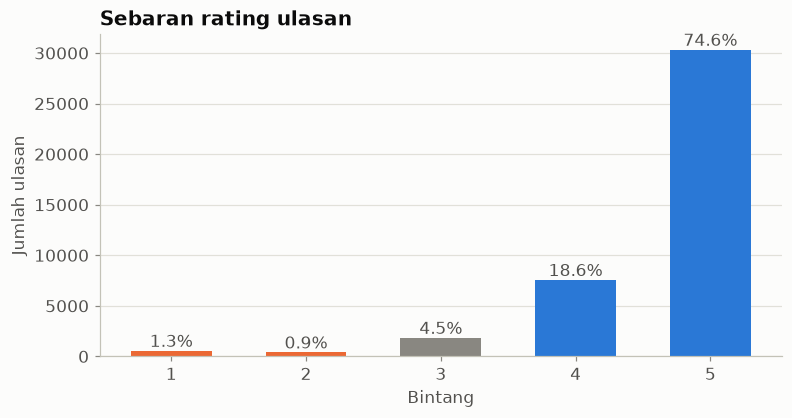

Ulasan negatif (bintang 1-2): 925 (2.3%)


In [4]:
sebaran = ulasan["rating"].value_counts().sort_index()
porsi = sebaran / sebaran.sum()

fig, ax = plt.subplots(figsize=(8, 3.8))
warna = [ps.ORANYE, ps.ORANYE, ps.MUTED, ps.BIRU, ps.BIRU]
ax.bar(sebaran.index.astype(str), sebaran.values, color=warna, width=0.6)
for i, (n, p) in enumerate(zip(sebaran.values, porsi.values)):
    ax.text(i, n + 400, f"{p:.1%}", ha="center", color=ps.INK_2)
ax.set_title("Sebaran rating ulasan")
ax.set_xlabel("Bintang")
ax.set_ylabel("Jumlah ulasan")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
plt.show()

print(f"Ulasan negatif (bintang 1-2): {ulasan['is_negatif'].sum():,} ({ulasan['is_negatif'].mean():.1%})")

**Tiga perempat ulasan memberi bintang 5**, dan ulasan negatif (bintang 1-2) hanya 2,3%. Artinya seluruh analisis keluhan di notebook ini bertumpu pada sekitar 900 ulasan saja.

Porsi ulasan negatif juga tidak merata antar kategori:

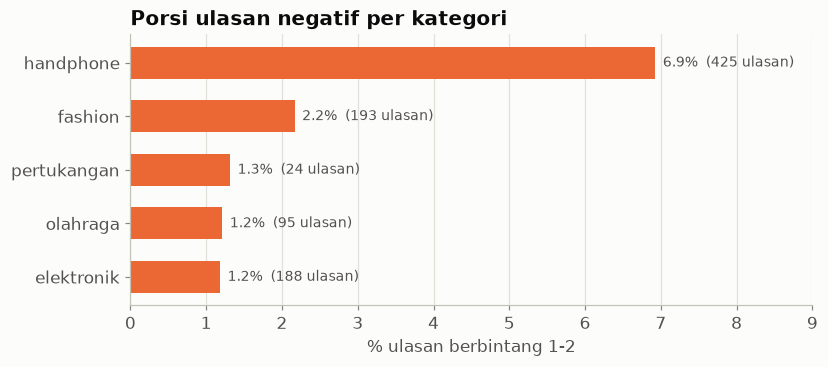

In [5]:
neg = ulasan.groupby("kategori")["is_negatif"].agg(["sum", "mean"]).sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(neg.index, neg["mean"] * 100, color=ps.ORANYE, height=0.6)
for i, (p, n) in enumerate(zip(neg["mean"], neg["sum"])):
    ax.text(p * 100 + 0.1, i, f"{p:.1%}  ({int(n)} ulasan)", va="center", color=ps.INK_2, fontsize=9)
ax.set_xlim(0, 9)
ax.set_title("Porsi ulasan negatif per kategori")
ax.set_xlabel("% ulasan berbintang 1-2")
plt.show()

**Handphone menonjol**: porsi ulasan negatifnya 6,9% — tiga kali fashion dan hampir enam kali elektronik maupun olahraga. Dugaannya — yang akan diperiksa di bagian 4 — barang elektronik kecil lebih rentan tidak berfungsi, dan ekspektasi pembelinya lebih tinggi.

Ada pola lain yang konsisten dengan intuisi: **pembeli yang kecewa menulis lebih panjang.**

In [6]:
(ulasan.groupby("rating")["panjang_ulasan"].median()
       .to_frame("median panjang ulasan (karakter)"))

,median panjang ulasan (karakter)
rating,
1,64.0
2,62.5
3,49.0
4,43.0
5,43.0


Ulasan bintang 1-2 median panjangnya sekitar 63 karakter, sedangkan bintang 4-5 hanya 43. Pembeli yang puas cukup menulis "mantap, terima kasih"; yang kecewa menjelaskan apa yang salah. Ini kabar baik untuk analisis: ulasan negatif, walau sedikit, justru paling kaya informasi.

## 3. Apa yang dipuji pembeli

*Saran Kaggle: Analyze product preferences across different categories.*

Keluhan hanya separuh cerita. Untuk memahami preferensi pembeli, ulasan bintang 4-5 juga dikelompokkan ke dalam tema pujian.

Daftar kata disusun setelah membaca sampel ulasan asli. Versi pertamanya punya kesalahan yang instruktif: kata "cepat" dimasukkan ke tema *pengiriman cepat*, padahal banyak pembeli menulis "respon seller **cepat**" — yang seharusnya masuk tema *penjual responsif*. Maka tema pengiriman kini hanya menghitung frasa yang jelas membahas pengiriman.

In [7]:
PUJIAN = {
    "Sesuai deskripsi": ["sesuai", "sama persis", "original", "ori", "asli"],
    "Penjual responsif": ["respon", "respons", "fast respon", "fast response", "ramah",
                          "pelayanan", "amanah", "seller", "penjual"],
    "Kualitas produk": ["kualitas", "berkualitas", "kokoh", "awet", "tebal", "halus",
                        "bahan bagus", "bahannya bagus", "kuat", "nyaman",
                        "berfungsi baik", "berfungsi dengan baik", "normal"],
    "Pengiriman cepat": ["pengiriman cepat", "pengiriman cepet", "pengirimannya cepat",
                         "kirim cepat", "cepat sampai", "cepat sampe", "cepet sampe",
                         "cepet sampai", "sampai cepat", "sampe cepat", "sampainya cepat",
                         "pengiriman kilat", "kilat", "ekspres"],
    "Pengemasan rapi": ["packing", "packingan", "kemasan", "rapi", "rapih", "bubble wrap", "aman"],
    "Harga sepadan": ["murah", "harga", "worth", "terjangkau", "ekonomis"],
}

positif = ulasan[ulasan["rating"] >= 4].copy()
teks = positif["ulasan"].str.lower()
for tema, kata in PUJIAN.items():
    pola = re.compile(r"\b(?:" + "|".join(map(re.escape, kata)) + r")(?:nya|kan|an)?\b")
    positif[tema] = teks.str.contains(pola)

tema_puji = list(PUJIAN)
print(f"Ulasan positif tanpa tema: {(~positif[tema_puji].any(axis=1)).mean():.1%}")
(positif[tema_puji].mean() * 100).sort_values(ascending=False).round(1).to_frame("% ulasan positif")

Ulasan positif tanpa tema: 40.3%


,% ulasan positif
Sesuai deskripsi,30.2
Penjual responsif,19.4
Kualitas produk,13.0
Pengiriman cepat,10.5
Pengemasan rapi,10.2
Harga sepadan,5.6


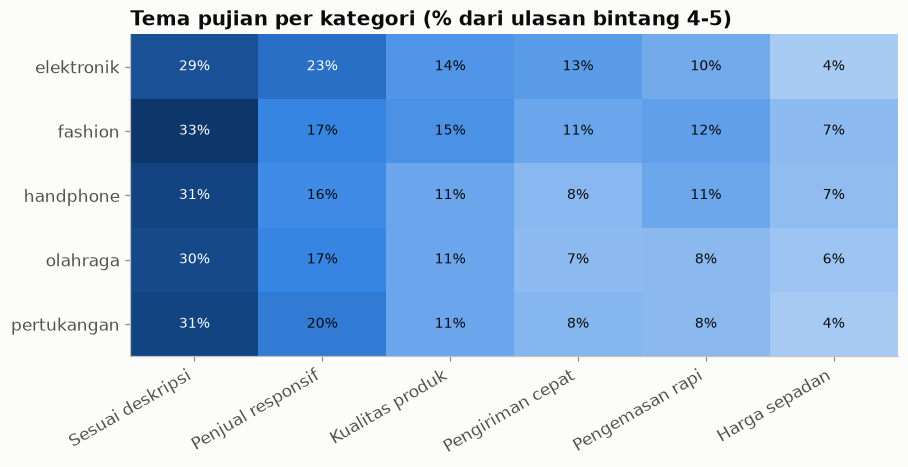

In [8]:
puji = positif.groupby("kategori")[tema_puji].mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.8))
heatmap(puji, ps.CMAP_BIRU, "Tema pujian per kategori (% dari ulasan bintang 4-5)", ax)
plt.show()

**Temuan:**

- **"Sesuai deskripsi" adalah pujian nomor satu di semua kategori** — disebut di sekitar 30% ulasan positif. Pembeli paling menghargai barang yang datang persis seperti yang dijanjikan.
- **Penjual yang responsif** menyusul di urutan kedua, terutama di elektronik (23%). Barang teknis sering memunculkan pertanyaan sebelum dan sesudah membeli.
- **Harga hampir tidak pernah dipuji** — hanya sekitar 6%. Pembeli yang puas tidak menyebut harga murah; mereka menyebut barang sesuai dan penjual yang responsif.

Sekitar 40% ulasan positif tidak tertangkap tema apa pun. Setelah dibaca, sebagian besarnya memang pujian umum tanpa alasan spesifik ("Mantap", "Terima kasih, barang sudah sampai"), jadi wajar tidak masuk tema mana pun.

## 4. Apa yang dikeluhkan pembeli

Tema keluhan diambil dari `src/review_analysis.py` — fungsi yang sama dengan dashboard. Daftar katanya juga disusun dari pembacaan ulasan asli, termasuk ejaan gaul ("tdk sesuai", "blm sampe"). Kata yang juga muncul dalam pujian sengaja tidak dipakai sendirian: "gambar" akan cocok dengan "barang *sesuai gambar*".

[reviews] ulasan negatif tanpa tema terdeteksi: 31.0%


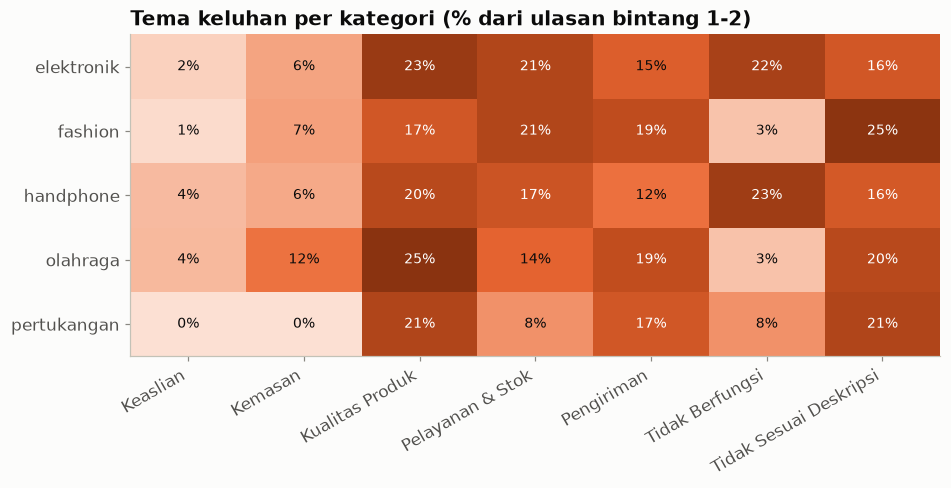

In [9]:
tema_keluhan = review_analysis.hitung_tema_keluhan(ulasan)
keluhan = tema_keluhan.pivot(index="kategori", columns="tema", values="porsi").fillna(0) * 100

fig, ax = plt.subplots(figsize=(9.5, 3.8))
heatmap(keluhan, ps.CMAP_ORANYE, "Tema keluhan per kategori (% dari ulasan bintang 1-2)", ax)
plt.show()

Satu ulasan bisa menyinggung lebih dari satu tema, jadi porsi per baris tidak berjumlah 100%.

**Temuan:**

- **Elektronik dan handphone**: keluhan terbesar adalah **barang tidak berfungsi** (22-23%) — charger tidak mengisi, tombol mati, sinyal tidak terdeteksi. Ini menjawab dugaan di bagian 2 soal tingginya ulasan negatif handphone.
- **Fashion**: keluhan terbesar adalah **tidak sesuai deskripsi** (25%) — ukuran, warna, dan model yang berbeda dari foto.
- **Olahraga**: keluhan **kualitas produk** paling tinggi (25%), dan keluhan **kemasan** dua kali kategori lain (12%) — wajar untuk barang besar seperti matras dan peralatan fitness.
- **Pertukangan** hanya punya 24 ulasan negatif. Angkanya ditampilkan untuk kelengkapan, tapi terlalu sedikit untuk disimpulkan.

Supaya angka ini bisa dipertanggungjawabkan, berikut contoh ulasan asli untuk setiap tema:

In [10]:
negatif = ulasan[ulasan["is_negatif"]].copy()
negatif["tema"] = negatif["ulasan"].apply(review_analysis.tandai_tema)

contoh = []
for tema in COMPLAINT_THEMES:
    cocok = negatif[negatif["tema"].apply(lambda t: tema in t)]
    for u in cocok["ulasan"].sample(min(2, len(cocok)), random_state=1):
        contoh.append({"tema": tema, "ulasan": u[:110]})
pd.DataFrame(contoh)

,tema,ulasan
0,Pengiriman,Sekelas official store begini nih? Demi rating pengiriman? Hahaha mending gausah di pr...
1,Pengiriman,"Pengirimnya lama, prosesnya juga lamaaaa"
2,Kemasan,"Packing rapi ,tapi barang ķotor ga sesuai merk dideskripsi,berdebu,ada yang bocel atau..."
3,Kemasan,Pertama ini toko besar tapi packing nya pelit sampe bungkus usb hubnya robek kedua sar...
4,Tidak Berfungsi,X ini saya kecewe gak bisa di pakai kecil dan mbranjang...
5,Tidak Berfungsi,Tombol hapus tidak berfungsi...
6,Kualitas Produk,Suara nya jelek bgd..nerima maupun telp..baterainya jg..gak d pake sehari habis..keypa...
7,Kualitas Produk,bagus baterai nya cpt habis tapi gk papa
8,Tidak Sesuai Deskripsi,sepatunya berbeda dengan fotonya ..... tingkatkan profesionalisme agar tidak memalukan...
9,Tidak Sesuai Deskripsi,"Walpaper dalam jam kacanya lecek setengah,ga sesuai dengan pict"


Dan ulasan negatif yang **tidak** tertangkap tema mana pun — bagian yang harus diakui secara terbuka:

In [11]:
lolos = negatif[negatif["tema"].str.len() == 0]
print(f"Ulasan negatif tanpa tema: {len(lolos)} dari {len(negatif)} ({len(lolos) / len(negatif):.1%})")
lolos[["rating", "ulasan"]].sample(10, random_state=4)

Ulasan negatif tanpa tema: 287 dari 925 (31.0%)


,rating,ulasan
18335,1,"Converter usb to vga tidak terpakai, saya masih tetap barus bayar. Semoga berkah ya.. ..."
9300,1,Beli 3. Cuma 1 yang bisa dipakai
8006,1,Barangnya udah connect tapi ga keluar suara
39364,1,bos ente bilang donic....itu kaga ada tulisan donic di karet atau d bungkus nya
5814,1,Kecewa dengan hp nya.. Ternyata suara nada dering nya aneh.. Tidak layaknya hp samsung.
7517,2,warna nya ga sesuaii dengan yg saya ingin kan
7878,2,"Charger untuk headset warna putih terdapat benda asing yg menghalangi lubang, mengakib..."
10192,1,hanya ini yg sampai.....
1236,1,Beli 5 tdk bs dipakai semua
12382,2,pesan tanggal 5 sampe tanggal 11 super sekali


Setelah dibaca, sisa yang lolos ternyata campuran tiga jenis:

1. **Kekecewaan umum** tanpa alasan spesifik ("Sangat kecewa", "parah") — memang tidak seharusnya masuk tema mana pun.
2. **Pujian dengan bintang rendah** ("Barang sesuai dengan pesanan") — kemungkinan pembeli salah menekan bintang.
3. **Keluhan spesifik yang luput dari aturan.** Ejaan yang belum terdaftar ("tdk **bs** dipakai", "ga **sesuaii**") atau kalimat tidak langsung ("Beli 3. Cuma 1 yang bisa dipakai") — yang terakhir bahkan tidak memuat kata negasi sama sekali.

Jenis ketiga adalah kelemahan nyata pendekatan berbasis aturan: daftar kata tidak pernah bisa lengkap, dan setiap tambalan hanya menangkap pola yang sudah terlihat. Aturannya sengaja **tidak** ditambal di sini supaya angka 31% tetap jujur. Pendekatan yang belajar langsung dari teks dicoba di notebook 03.

## 5. Pujian dan keluhan dalam satu gambar

Beberapa tema muncul di kedua sisi. Membandingkannya berdampingan menunjukkan aspek mana yang paling menentukan pengalaman pembeli:

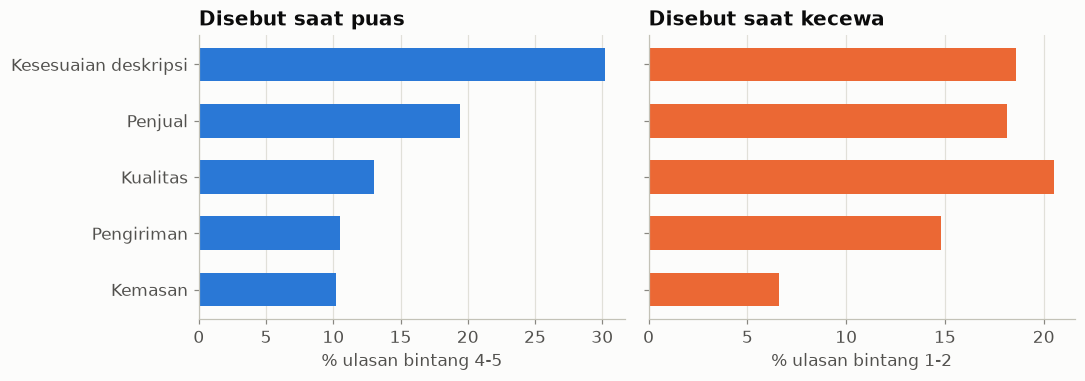

,dipuji (% ulasan positif),dikeluhkan (% ulasan negatif)
Kesesuaian deskripsi,30.2,18.6
Penjual,19.4,18.2
Kualitas,13.0,20.5
Pengiriman,10.5,14.8
Kemasan,10.2,6.6


In [12]:
pasangan = {
    "Kesesuaian deskripsi": ("Sesuai deskripsi", "Tidak Sesuai Deskripsi"),
    "Penjual": ("Penjual responsif", "Pelayanan & Stok"),
    "Kualitas": ("Kualitas produk", "Kualitas Produk"),
    "Pengiriman": ("Pengiriman cepat", "Pengiriman"),
    "Kemasan": ("Pengemasan rapi", "Kemasan"),
}
porsi_puji = positif[tema_puji].mean() * 100
porsi_keluh = (tema_keluhan.groupby("tema")["jumlah"].sum() / negatif.shape[0]) * 100

banding = pd.DataFrame({
    "dipuji (% ulasan positif)": [porsi_puji[p] for p, _ in pasangan.values()],
    "dikeluhkan (% ulasan negatif)": [porsi_keluh.get(k, 0) for _, k in pasangan.values()],
}, index=list(pasangan))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
y = banding.index[::-1]
a1.barh(y, banding.iloc[::-1, 0], color=ps.BIRU, height=0.6)
a1.set_title("Disebut saat puas")
a1.set_xlabel("% ulasan bintang 4-5")
a2.barh(y, banding.iloc[::-1, 1], color=ps.ORANYE, height=0.6)
a2.set_title("Disebut saat kecewa")
a2.set_xlabel("% ulasan bintang 1-2")
plt.tight_layout()
plt.show()
banding.round(1)

**Kesesuaian dengan deskripsi** adalah aspek paling menentukan: paling sering dipuji saat pembeli puas, dan salah satu keluhan terbesar saat kecewa. **Penjual** berada di posisi serupa. Keduanya sepenuhnya di bawah kendali penjual — berbeda dengan pengiriman, yang sebagian bergantung pada kurir.

**Kualitas** menunjukkan pola sebaliknya: paling sering dikeluhkan (sekitar 20%), tapi jarang dipuji (13%). Pembeli tampaknya menganggap kualitas yang layak sebagai hal yang sewajarnya — tidak disebut saat terpenuhi, tapi langsung dikeluhkan saat tidak. Kualitas adalah syarat minimum, bukan pembeda.

Implikasi praktis bagi penjual:

1. **Foto dan deskripsi yang akurat** — terutama ukuran dan warna di fashion — memberi dampak terbesar di kedua sisi.
2. **Cek fungsi sebelum kirim** untuk elektronik dan handphone, karena "tidak berfungsi" adalah keluhan nomor satu di sana.
3. **Bersaing lewat harga bukan cara mendapat ulasan bagus** — pembeli yang puas hampir tidak pernah menyebutnya.

## 6. Pemeriksaan silang dengan TF-IDF

Tema berbasis aturan bisa bias oleh daftar kata yang disusun sendiri. Sebagai pemeriksaan, TF-IDF mencari kata yang paling khas di ulasan negatif tiap kategori **tanpa** daftar kata apa pun. Kalau kedua metode sampai pada kesimpulan serupa, hasilnya lebih bisa dipercaya.

In [13]:
kata_menonjol = review_analysis.kata_menonjol_negatif(ulasan, top_n=8)
(kata_menonjol.groupby("kategori")["kata"]
    .apply(lambda s: ", ".join(s))
    .to_frame("kata paling khas di ulasan negatif (setelah stemming)"))

,kata paling khas di ulasan negatif (setelah stemming)
kategori,
elektronik,"kirim, usb, pakai, mouse, deskripsi, rusak, kabel, tombol"
fashion,"kirim, ukur, jam, size, sepatu, sangat, kecewa, minta"
handphone,"kirim, suara, warna, sama, fungsi, sangat, nyala, tgl"
olahraga,"jual, kirim, kualitas, kurang, ukur, sama, sangat, kecil"
pertukangan,"kirim, staples, isi, straples, jok, dulu, mungkin, isiya"


Kata-katanya sudah melalui *stemming* dengan Sastrawi, jadi "ukuran" muncul sebagai "ukur" dan "berfungsi" sebagai "fungsi".

Hasilnya sejalan dengan tema aturan: fashion memunculkan **"ukur" dan "size"** (masalah ukuran, bagian dari *tidak sesuai deskripsi*), sedangkan handphone memunculkan **"fungsi", "nyala", dan "suara"** (*tidak berfungsi*). Dua metode yang berbeda sampai pada kesimpulan yang sama.

## Ringkasan

| Temuan | Implikasi |
|---|---|
| 75% ulasan bintang 5; negatif hanya 2,3% | Analisis keluhan bertumpu pada sekitar 900 ulasan |
| Ulasan negatif handphone 3-6× kategori lain | Didorong keluhan barang tidak berfungsi |
| Ulasan negatif lebih panjang dari ulasan positif | Walau sedikit, paling kaya informasi |
| Kesesuaian deskripsi paling sering dipuji dan dikeluhkan | Akurasi foto dan deskripsi adalah pengungkit terbesar |
| Kualitas sering dikeluhkan tapi jarang dipuji | Kualitas adalah syarat minimum, bukan pembeda |
| Harga jarang disebut dalam ulasan positif | Kepuasan tidak didorong harga murah |

**Keterbatasan:**

- Data dari **2019**, hanya **lima kategori**, dan pertukangan hanya 24 ulasan negatif.
- Tema berbasis aturan: sekitar 31% ulasan negatif tidak tertangkap tema apa pun, dan sebagian di antaranya adalah keluhan spesifik yang luput karena ejaan atau kalimat tidak langsung. Di sisi positif, 40% tidak bertema, tapi umumnya memang pujian tanpa alasan spesifik.
- Satu ulasan bisa masuk beberapa tema, dan tema tidak membedakan tingkat keparahan keluhan.

Model yang mempelajari sentimen langsung dari teks — tanpa daftar kata buatan — dicoba di **notebook 03**.